In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

seaborn Pairs Panels — psych Vignette (_r2p)
============================================

Purpose:
    Demonstrates seaborn pairplot as the Python equivalent of R's
    psych::pairs.panels() function.

    psych::pairs.panels() produces in one figure:
      - Scatter plots (lower triangle)
      - Histograms or density on the diagonal
      - Correlation coefficients (upper triangle)

    Python equivalents:
      - seaborn.pairplot()         — scatter + KDE diagonal
      - Correlation annotations    — added via matplotlib text
      - seaborn.heatmap()          — alternative correlation view
      - pandas.DataFrame.corr()   — Pearson correlation matrix

    Dataset: iris — built into seaborn and sklearn
    R uses: iris[-5] (drop the 5th column: Species factor)
    Python: iris.drop(columns=['species'])

    R equivalent: psych_library_pairs.panels_vignette.Rmd
    R libraries:  psych
    Python libs:  pandas, numpy, matplotlib, seaborn, sklearn

    Note on R filename: The original R file had a dot in the middle
    (psych_library_pairs.panels_vignette.Rmd) — likely a typo.
    The Python filename uses the correct underscore convention.

    Suffix _r2p: This notebook was converted from R to Python.

Revision History:
    2023-01-01  Original R development (Harvard STAT 109)
                - R script: psych_library_pairs.panels_vignette.Rmd
                - Three lines: library(psych); pairs.panels(iris[-5])

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - psych::pairs.panels() → seaborn.pairplot()
                - Correlation coefficients annotated in upper triangle
                - Added: correlation heatmap, pairplot by species
                - iris[-5] → iris.drop(columns=['species'])
"""

"\nCreated on 2023-01-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nseaborn Pairs Panels — psych Vignette (_r2p)\n============================================\n\nPurpose:\n    Demonstrates seaborn pairplot as the Python equivalent of R's\n    psych::pairs.panels() function.\n\n    psych::pairs.panels() produces in one figure:\n      - Scatter plots (lower triangle)\n      - Histograms or density on the diagonal\n      - Correlation coefficients (upper triangle)\n\n    Python equivalents:\n      - seaborn.pairplot()         — scatter + KDE diagonal\n      - Correlation annotations    — added via matplotlib text\n      - seaborn.heatmap()          — alternative correlation view\n      - pandas.DataFrame.corr()   — Pearson correlation matrix\n\n    Dataset: iris — built into 

# seaborn Pairs Panels — psych Vignette

## Purpose

Demonstrates `seaborn.pairplot()` as the Python equivalent of R's
`psych::pairs.panels()` on the **iris dataset**.

**What `pairs.panels()` shows in one figure:**

| Position | R (psych) | Python (seaborn) |
|----------|-----------|------------------|
| Lower triangle | Scatter plots | `seaborn.pairplot()` scatter |
| Diagonal | Histogram / density | KDE or histogram |
| Upper triangle | Pearson r correlation | Annotated with `df.corr()` |

**R equivalent:** `psych_library_pairs.panels_vignette.Rmd` (3 lines of R)

**Note on filename:** The original R file had a dot in the middle
(`pairs.panels`) — a typo. Python filename uses correct underscore.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'

print('Imports complete.')

Imports complete.


## Load the iris Dataset

Mirrors R:
```r
# iris is built into R — no load needed
pairs.panels(iris[-5])   # iris[-5] drops the 5th column: Species
```

iris is built into both seaborn and sklearn — no install needed.

In [3]:
# Load iris — mirrors R: iris (built-in)
iris = sns.load_dataset('iris')

print(f'Shape: {iris.shape}')
print()
print('dtypes:')
print(iris.dtypes)
print()
iris.head()

Shape: (150, 5)

dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Numeric columns only — mirrors R: iris[-5] (drop Species factor)
iris_num = iris.drop(columns=['species'])   # iris[-5] equivalent

print(f'Numeric-only shape: {iris_num.shape}')
print(f'Columns: {list(iris_num.columns)}')
print()
iris_num.describe().round(3)

Numeric-only shape: (150, 4)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']



,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


---

## pairs.panels() — Direct Mirror

Mirrors R:
```r
library(psych)
pairs.panels(iris[-5])
```

The closest Python equivalent: `seaborn.pairplot()` with KDE on the diagonal
and Pearson r correlation coefficients annotated in the upper triangle.

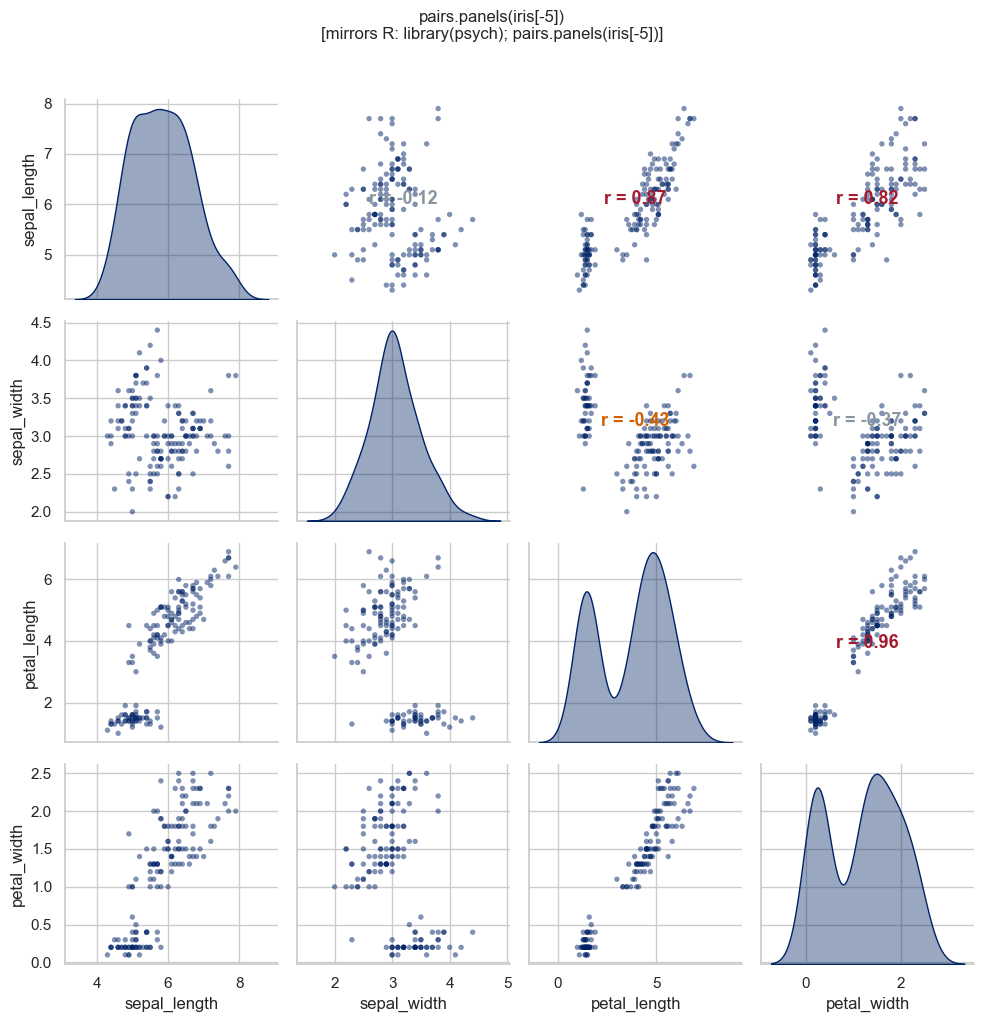

Correlation matrix (Pearson r):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [5]:
# pairs.panels(iris[-5]) — direct mirror
# seaborn.pairplot handles lower triangle (scatter) + diagonal (KDE)
# We add correlation coefficients in the upper triangle manually

g = sns.pairplot(iris_num,
                  diag_kind='kde',      # histogram on diagonal (mirrors pairs.panels default)
                  plot_kws={'alpha': 0.5, 's': 15,
                             'color': ROYALBLUE,
                             'edgecolors': 'none'},
                  diag_kws={'color': ROYALBLUE, 'fill': True, 'alpha': 0.4})

# Add Pearson r in upper triangle — mirrors psych::pairs.panels() upper panel
cols = iris_num.columns
corr = iris_num.corr()

for i, row_var in enumerate(cols):
    for j, col_var in enumerate(cols):
        if j > i:   # upper triangle only
            ax = g.axes[i, j]
            r  = corr.loc[row_var, col_var]
            # Color by magnitude — mirrors psych color coding
            color = CRIMSON if abs(r) > 0.7 else (SAFFRON if abs(r) > 0.4 else SLATE)
            ax.text(0.5, 0.5, f'r = {r:.2f}',
                    ha='center', va='center',
                    transform=ax.transAxes,
                    fontsize=13, fontweight='bold', color=color)
            ax.set_axis_off()   # clean upper triangle

g.figure.suptitle('pairs.panels(iris[-5])\n'
                   '[mirrors R: library(psych); pairs.panels(iris[-5])]',
                   y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print('Correlation matrix (Pearson r):')
print(corr.round(3))

---

## Pairplot by Species — Adding Color

The R `pairs.panels()` can color by group with `bg=as.numeric(iris$Species)`.
In seaborn, `hue='species'` does this cleanly.

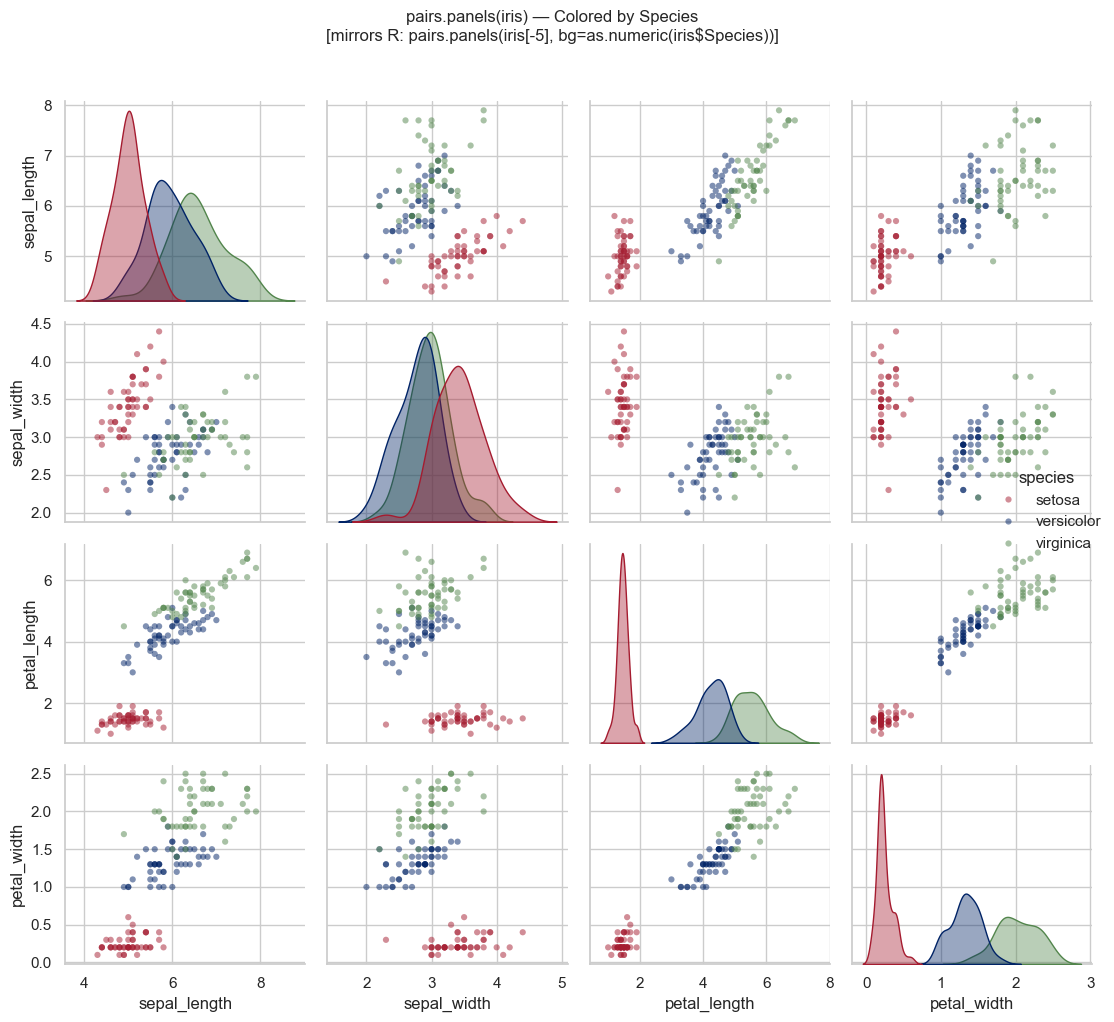

In [6]:
# Pairplot colored by species — mirrors R: pairs.panels(iris[-5], bg=as.numeric(iris$Species))
species_palette = {'setosa'    : CRIMSON,
                   'versicolor': ROYALBLUE,
                   'virginica' : IVY}

g2 = sns.pairplot(iris,
                   hue='species',
                   palette=species_palette,
                   diag_kind='kde',
                   plot_kws={'alpha': 0.5, 's': 20, 'edgecolors': 'none'},
                   diag_kws={'fill': True, 'alpha': 0.4})

g2.figure.suptitle('pairs.panels(iris) — Colored by Species\n'
                    '[mirrors R: pairs.panels(iris[-5], bg=as.numeric(iris$Species))]',
                    y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Correlation Heatmap — Alternative View

Not in the original R vignette — added as a Python extension.
Shows the same correlation information as the `pairs.panels()` upper
triangle, but in a standalone heatmap format.

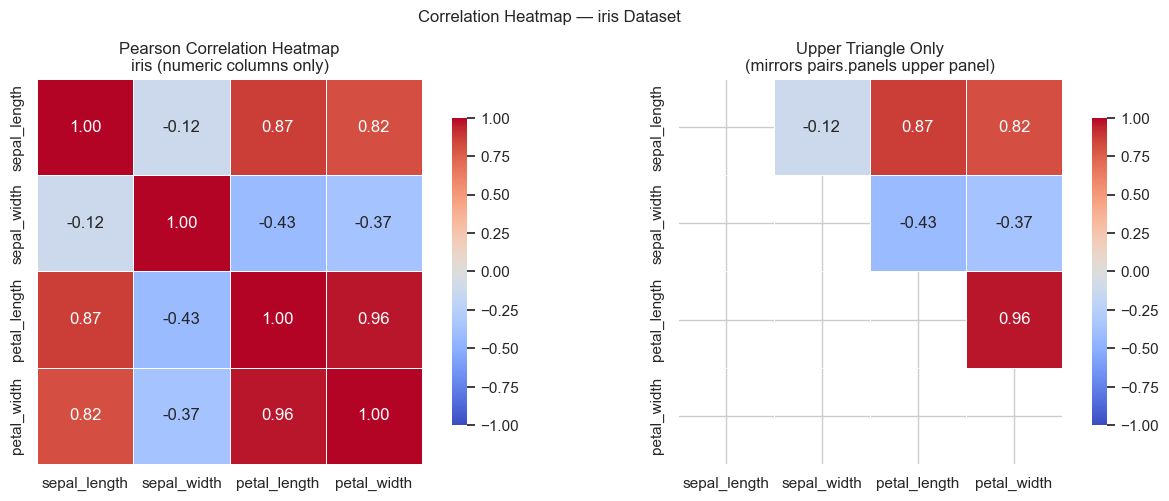

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full correlation heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Heatmap\niris (numeric columns only)')

# Upper triangle only — mirrors pairs.panels upper panel precisely
mask = np.tril(np.ones_like(corr, dtype=bool))   # mask lower + diagonal
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            mask=mask,
            ax=axes[1], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Upper Triangle Only\n(mirrors pairs.panels upper panel)')

fig.suptitle('Correlation Heatmap — iris Dataset', fontsize=12)
plt.tight_layout()
plt.show()

---

# Summary

## Key Takeaways

1. **`pairs.panels()` is three plots in one:** scatter (lower), density (diagonal),
   correlation r (upper). `seaborn.pairplot()` handles the scatter and diagonal;
   the upper triangle requires adding text annotations manually.

2. **Iris correlations:** petal_length and petal_width are highly correlated
   (r ≈ 0.96). sepal_width is weakly or negatively correlated with the others.
   These patterns are immediately visible in both the pairplot and heatmap.

3. **Adding `hue='species'`** reveals that the three species clusters are
   well-separated in petal dimensions but overlapping in sepal dimensions —
   the same insight that makes iris a classic ML benchmark dataset.

## R → Python Mapping

| R | Python |
|---|--------|
| `library(psych)` | `import seaborn as sns` |
| `pairs.panels(iris[-5])` | `sns.pairplot(iris_num, diag_kind='kde')` + corr annotations |
| `iris[-5]` (drop col 5) | `iris.drop(columns=['species'])` |
| Lower triangle: scatter | `sns.pairplot()` scatter (default) |
| Diagonal: histogram/density | `diag_kind='kde'` or `'hist'` |
| Upper triangle: Pearson r | `df.corr()` + `ax.text()` annotation |
| `bg=as.numeric(iris$Species)` | `hue='species', palette={...}` |
| *(no equivalent)* | `sns.heatmap(corr)` — clean standalone view |

## References

1. Harvard STAT 109, Dr. Bharatendra Rai.
2. psych R package: Revelle, W. (2024). psych: Procedures for Psychological,
   Psychometric, and Personality Research. Northwestern University.
3. Fisher, R.A. (1936). The use of multiple measurements in taxonomic problems.
   *Annals of Eugenics*, 7(2), 179-188. (iris dataset origin)
4. seaborn documentation: https://seaborn.pydata.org/generated/seaborn.pairplot.html